In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import cv2, os, json
from natsort import natsorted

In [2]:
%cd ..

/home/suetin/Projects/VSCode/UltrasoundCardiacReconstruction/HeartReconstruction


/home/suetin/Projects/VSCode/UltrasoundCardiacReconstruction/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
RV_seg_1_path = 'data/raw/RV_no_aug'
RV_seg_2_path = 'data/raw/RV_seg_aug_v1'
a4c_seg_path = 'data/raw/A4CSegmentation'

In [4]:
print(os.listdir(RV_seg_1_path))
print(os.listdir(RV_seg_2_path))
print(os.listdir(a4c_seg_path))

['train', 'data.yaml', 'test', 'valid']
['train', 'test', 'inference', 'valid']
['train', 'Inference', 'test', 'valid']


## RV_no_aug

This ds has labels like a YOLO

In [5]:
img_names = os.listdir(os.path.join(RV_seg_1_path, 'test', 'images'))
txt_names = os.listdir(os.path.join(RV_seg_1_path, 'test', 'labels'))

img_paths = natsorted([ os.path.join(RV_seg_1_path, 'test', 'images', img_name) for img_name in img_names ])
target_paths = natsorted([ os.path.join(RV_seg_1_path, 'test', 'labels', path) for path in txt_names ])

img_paths[:5], target_paths[:5], len(img_paths)

(['data/raw/RV_no_aug/test/images/106659-20120727131059_png.rf.1e3bdf11a6e81532d5324555efa19b80.jpg',
  'data/raw/RV_no_aug/test/images/107044-20180919112452-2-_png.rf.6f90b708d8af020c03568e16323ff1d2.jpg',
  'data/raw/RV_no_aug/test/images/108279-20170728102213_png.rf.3b971053cb9761040a6fcd678ffcc8f7.jpg',
  'data/raw/RV_no_aug/test/images/110252-20170505133550-2-_png.rf.4b75e7f4e099c8ef68be43ba738b7924.jpg',
  'data/raw/RV_no_aug/test/images/113309-20190122092054_png.rf.336800392d4704272bdca9b23140f148.jpg'],
 ['data/raw/RV_no_aug/test/labels/106659-20120727131059_png.rf.1e3bdf11a6e81532d5324555efa19b80.txt',
  'data/raw/RV_no_aug/test/labels/107044-20180919112452-2-_png.rf.6f90b708d8af020c03568e16323ff1d2.txt',
  'data/raw/RV_no_aug/test/labels/108279-20170728102213_png.rf.3b971053cb9761040a6fcd678ffcc8f7.txt',
  'data/raw/RV_no_aug/test/labels/110252-20170505133550-2-_png.rf.4b75e7f4e099c8ef68be43ba738b7924.txt',
  'data/raw/RV_no_aug/test/labels/113309-20190122092054_png.rf.336800

In [6]:
def prepare_txt(txt, img_shape=(512, 512)):
    """ """
    txt = txt[1:]  # Cut class
    xy = []
    # Transform to (x, y) format
    for i in range(0, len(txt), 2):
        x, y = txt[i], txt[i+1]
        if x < 1.0001:
            x, y = x * img_shape[0], y * img_shape[1]
        xy.append((x, y))

    return xy

In [7]:
def xy2img(frame, target, input_shape=(512, 512)):
    """ """
    
    mask = np.zeros_like(frame)

    points = np.array([[[xi, yi]] for xi, yi in target]).astype(np.int32)
    # points = points.sort_values(['x', 'y'])
    # print(points.shape)
    mask = cv2.fillPoly(mask, [points], color=[255,255,255])
    # mask = cv2.fillPoly(mask, [points], color=[255,255,255])
    # plt.imshow(mask);

    des = cv2.bitwise_not(mask)
    contour, hier = cv2.findContours(cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contour:
        cv2.drawContours(des, [cnt], 0, 255, -1)

    mask = cv2.bitwise_not(des)
    
    frame = cv2.resize(frame, input_shape)
    mask = cv2.resize(mask, input_shape)

    frame = frame / frame.max()
    # frame = np.transpose(frame, (2, 0, 1)) 

    return frame, mask

array([[ 41.749104 , 156.8417132],
       [ 52.3010752, 190.6890132],
       [ 60.5591396, 184.49162  ],
       [ 84.874552 , 183.5381752],
       [ 93.1326164, 183.5381752]])

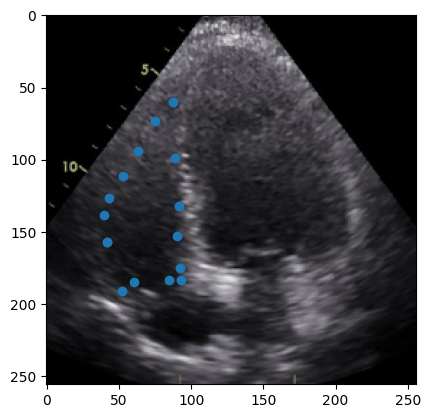

In [8]:
indx = -1

img = cv2.imread(img_paths[indx])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))

txt = np.loadtxt(target_paths[indx])
txt = prepare_txt(txt, img_shape=(256, 256))
xy = np.array(txt)

plt.imshow(img);
plt.scatter(xy[:, 0], xy[:, 1])
xy[:5]

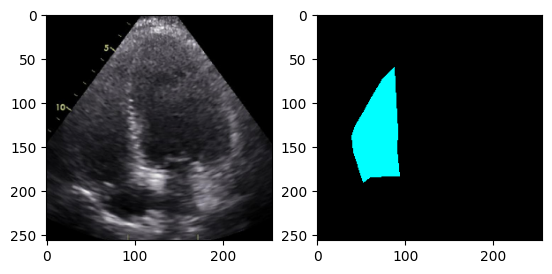

In [9]:
frame, mask = xy2img(img, txt, (256, 256))

plt.subplot(121)
plt.imshow(frame)
plt.subplot(122)
plt.imshow(mask);

## 2. RV_seg_aug_v1

We have .json labels format

In [10]:
with open(os.path.join(RV_seg_2_path, 'test', '_annotations.coco.json')) as f:
    lbl = json.load(f)

lbl.keys()

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

In [11]:
lbl['categories'], lbl['images'][0]

([{'id': 0, 'name': 'RV', 'supercategory': 'none'},
  {'id': 1, 'name': 'Diastole', 'supercategory': 'RV'},
  {'id': 2, 'name': 'Systole', 'supercategory': 'RV'}],
 {'id': 0,
  'license': 1,
  'file_name': '4044244-20150414084442-2-_png.rf.00b41703fb3f953b46ac3d5ebeb792e0.jpg',
  'height': 640,
  'width': 640,
  'date_captured': '2023-02-13T20:05:35+00:00'})

In [12]:
lbl['annotations'][0]

{'id': 0,
 'image_id': 0,
 'category_id': 2,
 'bbox': [180, 113, 97.659, 235],
 'area': 22949.926,
 'segmentation': [[182.044,
   338.125,
   191.526,
   345.625,
   262.637,
   348.125,
   258.844,
   326.875,
   257.896,
   251.875,
   268.326,
   164.375,
   277.807,
   113.125,
   244.622,
   143.125,
   222.815,
   169.375,
   199.111,
   221.875,
   184.889,
   279.375,
   180.148,
   321.875,
   182.044,
   338.125]],
 'iscrowd': 0}

In [13]:
len(lbl['annotations'])

65

In [42]:
lbl['images'][0]['width'], lbl['images'][0]['height']

(640, 640)

In [44]:
val = np.array(anno['segmentation']).reshape((-1, 2))
print(val.shape)

val[:, 0] / lbl['images'][0]['width']

(23, 2)


array([0.29481406, 0.29185156, 0.28740781, 0.29481406, 0.30370313,
       0.32148125, 0.35851875, 0.39851875, 0.41777813, 0.4429625 ,
       0.46222188, 0.4429625 , 0.42518594, 0.41037031, 0.39851875,
       0.39111094, 0.38370312, 0.36888906, 0.35259219, 0.33777812,
       0.3229625 , 0.30814844, 0.29481406])

In [13]:
stop

NameError: name 'stop' is not defined

In [15]:
def prepare_points(points):
    """ Prepared coordinates x and y like 1 row to write in file:
            cls x1 y1 x2 y2 ... xn yn, like YOLO format
        """
    print(points[:5])
    return [" ".join(map(str, xy)) for xy in points]

def coco2txt(main_path, labels):
    """ Transform COCO json format of dataset to YOLO .txt format """
    values = {}
    img_names = []
    # Go through labels. Get annotation and image id for downloading
    for annotation in labels['annotations']:
        img_indx = annotation['image_id']
        coords = np.array(annotation['segmentation']).reshape((-1, 2))
        img_name = labels['images'][img_indx]['file_name']

        img = cv2.imread(os.path.join(main_path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        values[img_name] = {"image": img, "RV": []}

        # Choose mask class. Also change class_id with our annotation: {"LV": 0, "LA": 1, "RV": 2, "RA": 3}, there indecies
        values[img_name]["RV"] = coords
        class_id = 3

        # 
        name = img_name.split(".")[-2]
        saved_path = "data/raw/RV_seg_aug_v1/inference"

        patient_path = os.path.join(saved_path, "masks", f"{name}.txt")

        with open(patient_path, "a") as file:
            # Scale
            coords[:, 0] = coords[:, 0] / labels['images'][img_indx]['width']
            coords[:, 1] = coords[:, 1] / labels['images'][img_indx]['height']
            points_2_txt = prepare_points(coords)
            file.write(f"{class_id} ")
            file.write(" ".join(map(str, points_2_txt)) +"\n")


        if os.path.exists(os.path.join(saved_path, "images")) == False:
            os.mkdir(os.path.join(saved_path, "images"))
        if os.path.exists(os.path.join(main_path, img_name)):
            # Move images to save path
            os.replace(os.path.join(main_path, img_name), os.path.join(saved_path, "images", img_name))

    print(len(img_names))

    return values

In [52]:
# values = coco2txt(os.path.join(RV_seg_2_path, 'test'), lbl)
# values

[[0.28444375 0.52832031]
 [0.29925937 0.54003906]
 [0.41037031 0.54394531]
 [0.40444375 0.51074219]
 [0.4029625  0.39355469]]
[[0.28592656 0.62988281]
 [0.30962969 0.62988281]
 [0.34370312 0.62207031]
 [0.37185156 0.62402344]
 [0.4        0.62207031]]
[[0.40592656 0.48925781]
 [0.42222187 0.18457031]
 [0.40888906 0.20410156]
 [0.37629688 0.27246094]
 [0.33481406 0.37988281]]
[[0.1570375  0.60449219]
 [0.16888906 0.62597656]
 [0.18666719 0.64355469]
 [0.20592656 0.65136719]
 [0.33185156 0.61230469]]
[[0.21925937 0.47753906]
 [0.23111094 0.54785156]
 [0.30222187 0.56542969]
 [0.37037031 0.56347656]
 [0.37185156 0.48535156]]
[[0.37010625 0.40527344]
 [0.35053438 0.34667969]
 [0.32918125 0.30566406]
 [0.32206406 0.35058594]
 [0.30605    0.40332031]]
[[0.21185156 0.40136719]
 [0.19555625 0.43652344]
 [0.18666719 0.49707031]
 [0.1970375  0.60253906]
 [0.23259219 0.60644531]]
[[0.35765156 0.49707031]
 [0.34875469 0.40332031]
 [0.32384375 0.26464844]
 [0.28469687 0.35058594]
 [0.25088906 0.444

In [18]:
with open(os.path.join(RV_seg_2_path, 'valid', '_annotations.coco.json')) as f:
    lbl = json.load(f)

print(lbl.keys())

values = coco2txt(os.path.join(RV_seg_2_path, 'valid'), lbl)
len(img_paths)

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
[[0.32918125 0.58105469]
 [0.37900312 0.59082031]
 [0.37900312 0.54003906]
 [0.37188594 0.42871094]
 [0.37010625 0.36425781]]
[[0.46962969 0.59082031]
 [0.45777813 0.45410156]
 [0.45777813 0.34667969]
 [0.42370313 0.41894531]
 [0.39111094 0.50488281]]
[[0.40569375 0.51171875]
 [0.41992813 0.41210938]
 [0.41815    0.34375   ]
 [0.40747344 0.30664062]
 [0.36654844 0.38867188]]
[[0.25185156 0.60839844]
 [0.2770375  0.62597656]
 [0.32592656 0.59667969]
 [0.35407344 0.54785156]
 [0.37333281 0.51074219]]
[[0.53037031 0.56738281]
 [0.5170375  0.43847656]
 [0.50518594 0.22558594]
 [0.45481406 0.30175781]
 [0.42666719 0.35449219]]
[[0.23555625 0.50097656]
 [0.36444375 0.51855469]
 [0.37777812 0.30566406]
 [0.39555625 0.19628906]
 [0.41037031 0.15332031]]
[[0.3879     0.54925625]
 [0.39679687 0.48791875]
 [0.39679687 0.40613437]
 [0.38612031 0.37639375]
 [0.34519531 0.41914531]]
[[0.34962969 0.59375   ]
 [0.36148125 0.5976562

65

In [19]:
with open(os.path.join(RV_seg_2_path, 'train', '_annotations.coco.json')) as f:
    lbl = json.load(f)

lbl.keys()

values = coco2txt(os.path.join(RV_seg_2_path, 'train'), lbl)
len(img_paths)

[[0.38078281 0.58300781]
 [0.37366563 0.53417969]
 [0.34519531 0.45800781]
 [0.33807813 0.47167969]
 [0.30960781 0.59863281]]
[[0.42074062 0.50878906]
 [0.42962969 0.42675781]
 [0.43851875 0.35058594]
 [0.44592656 0.29199219]
 [0.46074063 0.22753906]]
[[0.29481406 0.46191406]
 [0.31407344 0.52246094]
 [0.41185156 0.52050781]
 [0.40888906 0.35644531]
 [0.41777813 0.13574219]]
[[0.38074062 0.25878906]
 [0.39111094 0.16503906]
 [0.4        0.13183594]
 [0.35407344 0.19042969]
 [0.30222187 0.26855469]]
[[0.41037031 0.53613281]
 [0.38666719 0.41113281]
 [0.37481406 0.36035156]
 [0.36444375 0.30566406]
 [0.3629625  0.19824219]]
[[0.45925937 0.52246094]
 [0.46814844 0.21582031]
 [0.44444375 0.23535156]
 [0.42074062 0.26464844]
 [0.39111094 0.32714844]]
[[0.51555625 0.60644531]
 [0.48592656 0.52832031]
 [0.46814844 0.45605469]
 [0.45185156 0.40527344]
 [0.44       0.37597656]]
[[0.46619219 0.38940469]
 [0.45729531 0.44145   ]
 [0.44306094 0.50650625]
 [0.41992813 0.56412656]
 [0.41815    0.578

65

## 3. A4C

we alse have .json format for labels

In [34]:
stop

NameError: name 'stop' is not defined

In [13]:
with open(os.path.join(a4c_seg_path, 'test', '_annotations.coco.json')) as f:
    lbl = json.load(f)

lbl.keys()

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

In [14]:
lbl['categories'], lbl['images'][0]

([{'id': 0, 'name': 'Heart-Chambers', 'supercategory': 'none'},
  {'id': 1, 'name': 'left-atrium', 'supercategory': 'Heart-Chambers'},
  {'id': 2, 'name': 'left-ventricle', 'supercategory': 'Heart-Chambers'},
  {'id': 3, 'name': 'right-atrium', 'supercategory': 'Heart-Chambers'},
  {'id': 4, 'name': 'right-ventricle', 'supercategory': 'Heart-Chambers'}],
 {'id': 0,
  'license': 1,
  'file_name': 'a4c_image_131_png.rf.023926d3efa7f5554e4d69931d81a172.jpg',
  'height': 416,
  'width': 416,
  'date_captured': '2022-07-27T14:56:42+00:00'})

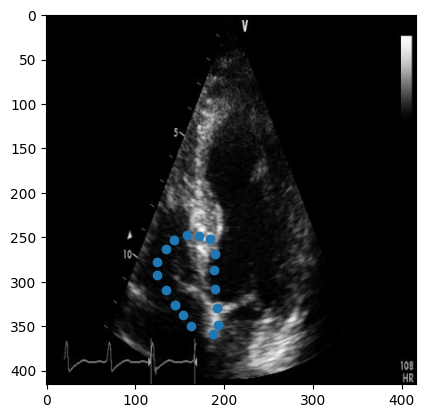

In [15]:
indx = 4

img_path = os.path.join(a4c_seg_path, 'test', lbl['images'][indx]['file_name'])
img = cv2.imread(img_path)
coords = lbl['annotations'][indx]['segmentation']

plt.imshow(img)

coords = np.array(coords).reshape((-1, 2))
plt.scatter(coords[:, 0], coords[:, 1])

In [16]:
lbl['annotations'][indx]

{'id': 4,
 'image_id': 6,
 'category_id': 3,
 'bbox': [124, 247, 68.46908500000002, 111.33537799999999],
 'area': 7623.031459789132,
 'segmentation': [[144.757592,
   326.467801,
   153.989379,
   338.065235,
   162.836508,
   349.66267,
   187.454606,
   358.360747,
   192.455157,
   349.082799,
   192.070499,
   329.367159,
   189.377895,
   308.491775,
   188.223922,
   286.456649,
   189.377895,
   269.060496,
   184.377344,
   252.244215,
   171.683637,
   248.764984,
   158.220615,
   247.025369,
   143.218961,
   252.824087,
   133.987174,
   262.681907,
   123.986072,
   277.758573,
   123.986072,
   292.255366,
   133.987174,
   309.651519,
   144.757592,
   326.467801]],
 'iscrowd': 0}

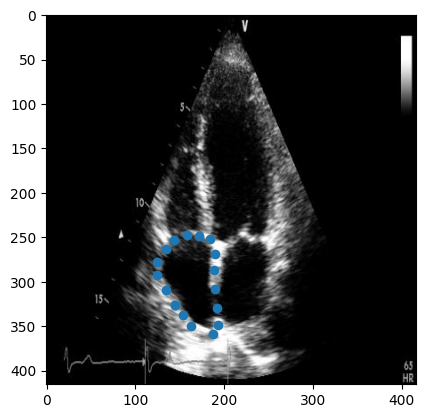

In [17]:
img_path = os.path.join(a4c_seg_path, 'test', lbl['images'][6]['file_name'])
img = cv2.imread(img_path)

plt.imshow(img)
plt.scatter(coords[:, 0], coords[:, 1])

In [18]:
len(img_paths), len(target_paths)

(65, 65)

In [ ]:
values = coco2txt(os.path.join(a4c_seg_path, 'test'), lbl)

In [31]:
def prepare_points(points):
    """ Prepared coordinates x and y like 1 row to write in file:
            cls x1 y1 x2 y2 ... xn yn, like YOLO format
        """
    print(points[:5])
    return [" ".join(map(str, xy)) for xy in points]

def coco2txt(main_path, labels):
    """ Transform COCO json format of dataset to YOLO .txt format """
    values = {}
    img_names = []
    # Go through labels. Get annotation and image id for downloading
    for annotation in labels['annotations']:
        img_indx = annotation['image_id']
        coords = np.array(annotation['segmentation']).reshape((-1, 2))
        img_name = labels['images'][img_indx]['file_name']
        if img_name not in(img_names):
            img_names.append(img_name)
            img = cv2.imread(os.path.join(main_path, img_name))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            values[img_name] = {"image": img, "LV": [], "LA": [], "RV": [], "RA": []}
        # Choose mask class. Also change class_id with our annotation: {"LV": 0, "LA": 1, "RV": 2, "RA": 3}, there indecies
        if annotation['category_id'] == 1:
            values[img_name]["LA"] = coords
            class_id = 2
        elif annotation['category_id'] == 2:
            values[img_name]["LV"] = coords
            class_id = 1
        elif annotation['category_id'] == 3:
            values[img_name]["RA"] = coords
            class_id = 4
        elif annotation['category_id'] == 4:
            values[img_name]["RV"] = coords
            class_id = 3

        # 
        name = img_name.split(".")[-2]
        saved_path = "data/raw/A4CSegmentation/Inference"

        patient_path = os.path.join(saved_path, "masks", f"{name}.txt")
        with open(patient_path, "a") as file:
            # Scale
            try:
                coords[:, 0] = coords[:, 0] / labels['images'][img_indx]['width']
                coords[:, 1] = coords[:, 1] / labels['images'][img_indx]['height']
                points_2_txt = prepare_points(coords)
                file.write(f"{class_id} ")
                file.write(" ".join(map(str, points_2_txt)) +"\n")
            except:
                print(f"WE HAVE: {coords}")
            

        if os.path.exists(os.path.join(saved_path, "images")) == False:
            os.mkdir(os.path.join(saved_path, "images"))
        if os.path.exists(os.path.join(main_path, img_name)):
            # Move images to save path
            os.replace(os.path.join(main_path, img_name), os.path.join(saved_path, "images", img_name))

    print(len(img_names))

    return values

In [30]:
values = coco2txt(os.path.join(a4c_seg_path, 'test'), lbl)
len(img_paths)

023926d3efa7f5554e4d69931d81a172
[[  0.47002985   0.8056872 ]
 [194.378446   345.603568  ]
 [196.301735   351.402286  ]
 [220.150518   353.721773  ]
 [231.690251   350.822414  ]]
023926d3efa7f5554e4d69931d81a172
[[  0.43859148   0.46696404]
 [183.22337    213.97268   ]
 [182.069397   231.948704  ]
 [185.146659   250.5046    ]
 [203.994891   262.102035  ]]
023926d3efa7f5554e4d69931d81a172
[[3.08214680e-01 7.31809310e-01]
 [1.39372383e+02 3.11971006e+02]
 [1.45911566e+02 3.22988570e+02]
 [1.53604721e+02 3.41544466e+02]
 [1.67837059e+02 3.53721773e+02]]
0e7e74aa6e4a72afbf241bbe05a48b72
[[  0.32023524   0.62168943]
 [151.296775   255.723446  ]
 [161.682534   248.764984  ]
 [173.222268   251.664344  ]
 [181.684739   238.327293  ]]
0e7e74aa6e4a72afbf241bbe05a48b72
[[3.47974981e-01 7.84778368e-01]
 [1.53989379e+02 3.38065235e+02]
 [1.62836508e+02 3.49662670e+02]
 [1.87454606e+02 3.58360747e+02]
 [1.92455157e+02 3.49082799e+02]]
0e7e74aa6e4a72afbf241bbe05a48b72
[[  0.48944768   0.84471703]
 [2

65

In [32]:
with open(os.path.join(a4c_seg_path, 'train', '_annotations.coco.json')) as f:
    lbl = json.load(f)

lbl.keys()

values = coco2txt(os.path.join(a4c_seg_path, 'train'), lbl)
len(img_paths)

[[  0.4293449    0.60635629]
 [181.684739   279.498188  ]
 [203.225575   285.296906  ]
 [212.457362   276.598829  ]
 [228.612989   275.439086  ]]
[[  0.53845456   0.90744355]
 [244.768616   371.117926  ]
 [251.307798   352.56203   ]
 [248.615193   338.065235  ]
 [243.9993     327.627544  ]]
[[3.58146221e-01 8.36353498e-01]
 [1.74376241e+02 3.58360747e+02]
 [1.80915424e+02 3.45023697e+02]
 [1.77838161e+02 3.20089211e+02]
 [1.75145557e+02 2.88776136e+02]]
[[  0.33780374   0.42375244]
 [131.29457    193.677167  ]
 [125.909361   206.434347  ]
 [115.523601   233.108447  ]
 [111.292365   252.244215  ]]
[[  0.57489954   0.72643292]
 [262.69788    291.675057  ]
 [269.672545   270.632859  ]
 [268.364841   221.315338  ]
 [260.954163   178.573485  ]]
[[  0.55289402   0.97460117]
 [241.337804   378.473852  ]
 [246.568887   346.253059  ]
 [247.004766   321.265545  ]
 [243.5174     302.196093  ]]
[[2.47960257e-01 8.02305954e-01]
 [1.00535959e+02 3.52171173e+02]
 [1.06638833e+02 3.74528459e+02]
 [1.2

65

In [33]:
with open(os.path.join(a4c_seg_path, 'valid', '_annotations.coco.json')) as f:
    lbl = json.load(f)

lbl.keys()

values = coco2txt(os.path.join(a4c_seg_path, 'valid'), lbl)
len(img_paths)

[[  0.5088655    0.59659883]
 [222.073807   248.185113  ]
 [238.229433   256.303318  ]
 [249.769167   241.226651  ]
 [252.846429   213.97268   ]]
[[  0.50146823   0.90604962]
 [220.535176   368.798439  ]
 [238.614091   355.461388  ]
 [243.614642   334.586005  ]
 [243.229984   316.030108  ]]
[[3.23933870e-01 8.14050740e-01]
 [1.59374588e+02 3.47923055e+02]
 [1.76684188e+02 3.40964594e+02]
 [1.77838161e+02 3.08491775e+02]
 [1.80915424e+02 2.80657931e+02]]
[[2.85098228e-01 6.76052413e-01]
 [1.15908258e+02 2.95734597e+02]
 [1.15908258e+02 3.14290493e+02]
 [1.22832098e+02 3.25887928e+02]
 [1.36295121e+02 3.39224979e+02]]
[[  0.48020109   0.86701979]
 [218.996544   370.538054  ]
 [235.536829   368.218567  ]
 [242.460669   352.56203   ]
 [245.153273   330.526903  ]]
[[  0.48852302   0.64538612]
 [219.765859   265.001394  ]
 [234.382855   260.942291  ]
 [245.153273   249.924728  ]
 [248.230536   226.729858  ]]
[[2.79550279e-01 7.70839142e-01]
 [1.36295121e+02 3.39224979e+02]
 [1.49758143e+02 3

65

In [52]:
values['a4c_image_131_png.rf.023926d3efa7f5554e4d69931d81a172.jpg'].keys()

dict_keys(['image', 'LV', 'LA', 'RV', 'RA'])

In [53]:
values['a4c_image_131_png.rf.023926d3efa7f5554e4d69931d81a172.jpg']['LA']

array([[195.532419, 335.165877],
       [194.378446, 345.603568],
       [196.301735, 351.402286],
       [220.150518, 353.721773],
       [231.690251, 350.822414],
       [242.076011, 341.544466],
       [247.845878, 324.148313],
       [247.46122 , 318.929468],
       [250.153825, 304.432673],
       [254.000402, 292.255366],
       [255.539034, 278.338444],
       [254.000402, 262.681907],
       [250.538482, 252.824087],
       [240.922038, 249.924728],
       [230.920935, 246.445498],
       [219.381202, 248.764984],
       [207.456811, 257.463061],
       [200.148313, 267.900753],
       [194.763104, 282.977419],
       [191.753607, 307.332032],
       [190.14721 , 307.911904],
       [192.839815, 317.769724],
       [195.532419, 335.165877]])

TypeError: list indices must be integers or slices, not tuple

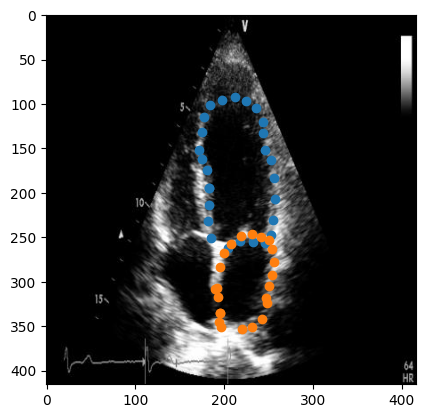

In [54]:
example = values['a4c_image_131_png.rf.023926d3efa7f5554e4d69931d81a172.jpg']

plt.imshow(example['image'])

plt.scatter(example["LV"][:, 0], example["LV"][:, 1]);
plt.scatter(example["LA"][:, 0], example["LA"][:, 1]);
plt.scatter(example["RV"][:, 0], example["RV"][:, 1]);
plt.scatter(example["RA"][:, 0], example["RA"][:, 1]);

In [58]:
values.keys()

dict_keys(['a4c_image_131_png.rf.023926d3efa7f5554e4d69931d81a172.jpg', 'a4c_image_129_png.rf.0e7e74aa6e4a72afbf241bbe05a48b72.jpg', 'a4c_image_217_png.rf.1dd882b30eb0bc1b5f9f609f65126a4a.jpg', 'a4c_image_104_png.rf.2fab72ebe6acf212ba6514ee18cc7c46.jpg', 'a4c_image_430_png.rf.587fb87d5c5d39478b2ee328c2596667.jpg', 'a4c_image_160_png.rf.49dddb17fb4fc4901c3b89e16d9dc74e.jpg', 'a4c_image_165_png.rf.7ee76081b5ed483250fad1dd79f4c660.jpg', 'a4c_image_151_png.rf.3d24bebaa61f7a59ab14e906ae53a126.jpg', 'a4c_image_182_png.rf.826025174d49501e105b485125d304c8.jpg', 'a4c_image_111_png.rf.879b33561dc105de7d9f685baf84e1aa.jpg', 'a4c_image_381_png.rf.948e15fb9ea51e1b99b3ee872d0ce03e.jpg', 'a4c_image_326_png.rf.badded75b549b6b9290b85ff1c0aea9b.jpg', 'a4c_image_154_png.rf.cbd7ad9d90c021b6f82e00d6b332eac9.jpg', 'a4c_image_114_png.rf.d029b00e1c67f92420adfef4c44c2286.jpg'])

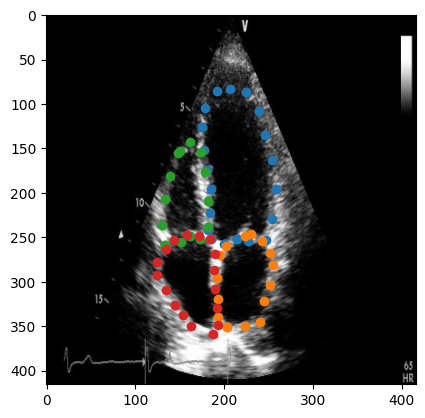

In [59]:
example = values['a4c_image_129_png.rf.0e7e74aa6e4a72afbf241bbe05a48b72.jpg']

plt.imshow(example['image'])

plt.scatter(example["LV"][:, 0], example["LV"][:, 1]);
plt.scatter(example["LA"][:, 0], example["LA"][:, 1]);
plt.scatter(example["RV"][:, 0], example["RV"][:, 1]);
plt.scatter(example["RA"][:, 0], example["RA"][:, 1]);